The chosen text material for training was Dostoyevsky's Crime and Punishment. The book has a distinct and a tad jumbled style and could lend itself to fun generative outputs.

In [1]:
# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'torch'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm
from keras import backend as K

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.14.0
Keras backend: torch


In [2]:
import torch
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
print(f"Number of GPUs found: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch CUDA available: True
Number of GPUs found: 1
GPU Name: NVIDIA GeForce RTX 5080


In [3]:
# Cell 2: Load and prepare text data
# Load the Crime and Punishment text
with open('./Crime_and_Punishment.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 138677 characters
First 100 characters: CRIME AND PUNISHMENT

PART I

CHAPTER I

On an exceptionally hot evening early in July a young man c


In [4]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'cnp_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 10000  # You can adjust this based on your needs
model_prefix = 'cnp_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "He was so badly dressed that even a man accustomed to shabbiness would have been ashamed to be seen in the street in such rags."
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁He', '▁was', '▁so', '▁badly', '▁dressed', '▁that', '▁even', '▁a', '▁man', '▁accustomed', '▁to', '▁shabbiness', '▁would', '▁have', '▁been', '▁ashamed', '▁to', '▁be', '▁seen', '▁in', '▁the', '▁street', '▁in', '▁such', '▁rags', '.']
Vocabulary size: 10000


In [5]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 30638
Number of sequences: 30574
Input shape: (30574, 64)
Target shape: (30574, 64)


### Hyperparameter Adjustments

Embed dims was increased from 128 to 300, along with ff_dim to 600 with the total parameter count going from ~4M to ~8M. This seemed to increase the accuracy during training but the quality of outputs during prompting stayed visually similar. The model produced less gibberish and seemed to grasp the meaning of words better.  Dropping tokenizer sequence length reduced coherence greatly as it started capturing smaller and smaller pieces of text structures. seq_length of 64 seemed okay when it came to the trade-off between memory usage and coherence. Raising sequence length lengthens training time significantly. Going from 64 to 128 increased per epoch times from 10s to 22s and caused 16GB GPU OOM. 

In [6]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 300
num_heads = 4
ff_dim = 600
num_layers = 3

# Create the model (no torch.device context needed)
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

# After compilation, verify GPU usage
if torch.cuda.is_available():
    print(f"\n✓ GPU is available and will be used: {torch.cuda.get_device_name(0)}")
    print(f"✓ Keras backend: {keras.config.backend()}")
else:
    print("\n✗ GPU not available, using CPU")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 300)   │  3,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 300)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 300)   │    361,200 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 300)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 300)   │        600 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 300)   │    360,900 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 300)   │        600 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 300)   │    361,200 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 300)   │        600 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 300)   │    360,900 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 300)   │        600 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 300)   │    361,200 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 64, 300)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten

 Total params: 8,179,900 (31.20 MB)

 Trainable params: 8,179,900 (31.20 MB)

 Non-trainable params: 0 (0.00 B)


✓ GPU is available and will be used: NVIDIA GeForce RTX 5080
✓ Keras backend: torch


In [7]:
# Cell 6: training
batch_size = 256 
epochs = 100

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    device = 'cuda'
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    
    # Keep tensors on CPU
    train_inputs_tensor = torch.tensor(train_inputs, dtype=torch.long)
    train_targets_tensor = torch.tensor(train_targets, dtype=torch.long)
    val_inputs_tensor = torch.tensor(val_inputs, dtype=torch.long)
    val_targets_tensor = torch.tensor(val_targets, dtype=torch.long)
else:
    device = 'cpu'
    train_inputs_tensor = torch.tensor(train_inputs, dtype=torch.long)
    train_targets_tensor = torch.tensor(train_targets, dtype=torch.long)
    val_inputs_tensor = torch.tensor(val_inputs, dtype=torch.long)
    val_targets_tensor = torch.tensor(val_targets, dtype=torch.long)

# Create datasets
train_dataset = torch.utils.data.TensorDataset(train_inputs_tensor, train_targets_tensor)
val_dataset = torch.utils.data.TensorDataset(val_inputs_tensor, val_targets_tensor)

# DataLoader with memory optimization
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    pin_memory=True,
    num_workers=4,
    persistent_workers=False,  # Changed to False to prevent memory leaks
    prefetch_factor=2  # Limit prefetching
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=batch_size,
    pin_memory=True,
    num_workers=4,
    persistent_workers=False,
    prefetch_factor=2
)

# Custom callback to clear memory after each epoch
class ClearMemoryCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            # Print memory usage
            if epoch % 5 == 0:  # every 5 epochs
                allocated = torch.cuda.memory_allocated(0) / 1e9
                reserved = torch.cuda.memory_reserved(0) / 1e9
                print(f"  GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")

# Enable garbage collection
import gc

# Standard fit + clear memory callback
print("Starting training with memory cleanup...")
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=epochs,
    callbacks=[
        ClearMemoryCallback(),
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('cnp_best_model.keras', save_best_only=True)
    ],
    verbose=1 
)

# Final cleanup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Using GPU: NVIDIA GeForce RTX 5080
Starting training with memory cleanup...
Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0511 - loss: 8.6321  GPU Memory - Allocated: 1.65GB, Reserved: 2.47GB
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - accuracy: 0.0603 - loss: 8.1507 - val_accuracy: 0.0639 - val_loss: 7.2647 - learning_rate: 5.0000e-05
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 120ms/step - accuracy: 0.0637 - loss: 6.8025 - val_accuracy: 0.0639 - val_loss: 6.4631 - learning_rate: 5.0000e-05
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.0637 - loss: 6.3546 - val_accuracy: 0.0639 - val_loss: 6.2897 - learning_rate: 5.0000e-05
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.0637 - loss: 6.2691 - val_accuracy: 0.0639 - val_loss: 6.2543 - learning_rate: 5.0000e-05
Epoch 5/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.0637 - loss: 6.2458 - val_accuracy: 0.0639 - val_loss: 6.2396 - learning_rate: 5.0000e-05
Epoch 6/10

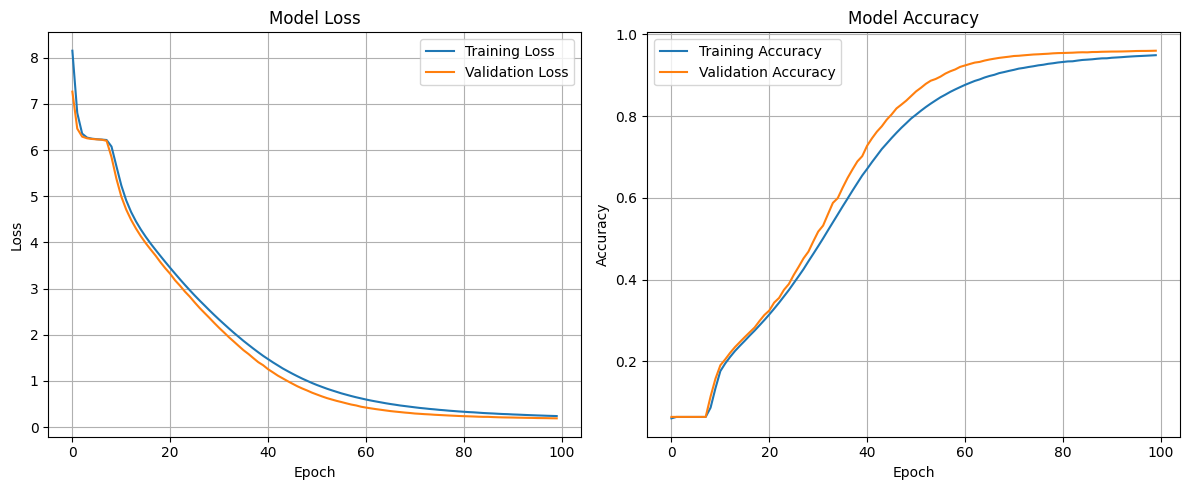

In [8]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Cell 8: Save the model
model.save('cnp_model.keras')
print("Model saved as 'cnp_model.keras'")

Model saved as 'cnp_model.keras'


In [10]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [14]:
# Cell 10: Generate sample text
prompts = [
    "The streets were stinky.",
    "The dark",
    "Police",
    "Vivid",
    "livid",
    "art",
    "Who was it?",
]

temp = 0.5

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=temp)
    temp += 0.2
    print(f"Temperature: {temp:.2f}")
    print(generated)


Prompt: The streets were stinky.
Temperature: 0.70
The streets were stinky. He was pale when his eyes again, glittering in the darkness. But, seeing a number of people on the landing, she grew bolder, and opened the door wide. The young man stepped into the dark entry, which was partitioned off from the tiny kitchen. The old woman stood facing him in silence and looking inquiringly at him. She was a diminutive, withered up old woman of sixty, with sharp malignant eyes and a sharp little nose. Her colourless, somewhat grizzled hair was thickly smeared with oil,

Prompt: The dark
Temperature: 0.90
The dark and Katerina Ivanovna was walking up and down and wringing her hands, her cheeks flushed red, as they always are in that disease: ‘Here you live with us,’ says she, ‘you eat and drink and are kept warm and you do nothing to give me about thefive, but for before I dare say! They imagine it is arranged now and can’t be broken off; but we will see whether it can or not! A magnificent exc

Observing different prompts and temperatures reveals that under temperature=1.0 the model starts copying word for word bits of the dataset. Higher temps (increased randomness) cause the model to decohere since the dataset is so small.

Batch size 256 was the highest my 16GB GPU could go before I started to run the risk of running OOM during training. Transformer models are difficult to train from scratch, as the amount of calculations during gradient decent is mind-boggling.

An LLM was used as help to set up PyTorch with the correct CUDA version, memory cleanup logic and the conversion of training data to torch tensors for training on the GPU.